# Case-Study LEAN Parity: Real Book Artifacts

**Docker image**: `ml4t`

The canonical benchmark in `15_lean_engine_parity` proves that
`ml4t-backtest[lean]` reproduces QuantConnect LEAN on the library's 250-asset,
20-year daily validation harness. This notebook answers the transfer
question readers actually care about: does that same calibrated profile still
match LEAN when we feed it the real case-study weights and price artifacts
used throughout the book?

**Learning Objectives**:
- Reuse the shared case-study validation artifacts with actual LEAN
- Compare `ml4t-backtest[lean]` directly against live LEAN, not against a second `ml4t` profile
- Distinguish raw trade-log row order from the economic fill surface we validate
- Inspect a cached parity snapshot and optionally rerun the live comparison locally

**Book Reference**: Chapter 16, Section 16.3 (Vectorized and Event-Driven Backtesting)

**Prerequisites**: `07_engine_divergence_anatomy` and `15_lean_engine_parity`

## Setup

In [1]:
"""Case-study LEAN parity on real book artifacts."""

import json
import shutil
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import ml4t.backtest as ml4t_backtest_pkg
import polars as pl

from case_studies.utils.analytics import SHORT_NAMES
from utils import ML4T_DATA_PATH
from utils.paths import get_chapter_dir, get_output_dir
from utils.style import COLORS

In [3]:
# Production defaults — Papermill injects overrides after this cell
RUN_LIVE = False
CASE_STUDIES = "etfs,sp500_equity_option_analytics,us_equities_panel"
MAX_CASE_STUDIES = 0  # 0 = all requested

In [4]:
OUTPUT_DIR = get_output_dir(16, "case_study_lean_parity")
RESULTS_PATH = OUTPUT_DIR / "case_study_lean_parity.csv"
CACHED_ARTIFACT_PATH = get_chapter_dir(16) / "resources" / "case_study_lean_parity_results.json"
LIVE_ARTIFACT_PATH = OUTPUT_DIR / "case_study_lean_parity_live.json"

## 1. Resolve the Validation Context

The live rerun path depends on the sibling `ml4t-backtest` repository because
the heavy LEAN orchestration lives in its internal validation layer, not in
the public runtime API.

In [5]:
def resolve_backtest_repo() -> Path | None:
    """Resolve the sibling ml4t-backtest repository root.

    Returns None when the validation harness is not available (e.g. CI),
    which disables the live rerun path but lets the cached artifact work.
    """
    package_path = Path(ml4t_backtest_pkg.__file__).resolve()
    for parent in package_path.parents:
        if (parent / "validation" / "benchmark_suite.py").exists():
            return parent

    fallback = Path.home() / "ml4t" / "libraries" / "ml4t-backtest"
    if (fallback / "validation" / "benchmark_suite.py").exists():
        return fallback

    return None


BACKTEST_REPO = resolve_backtest_repo()
LEAN_WORKSPACE = BACKTEST_REPO / "validation" / "lean" / "workspace" if BACKTEST_REPO else None
LEAN_CONFIG = LEAN_WORKSPACE / "lean.json" if LEAN_WORKSPACE else None

print(f"Backtest repo:  {BACKTEST_REPO or 'not found (cached artifact only)'}")
print(f"LEAN config:    {LEAN_CONFIG or 'not found'}")
print(f"ML4T_DATA_PATH: {ML4T_DATA_PATH}")

Backtest repo:  ~/ml4t/libraries/ml4t-backtest
LEAN config:    ~/ml4t/libraries/ml4t-backtest/validation/lean/workspace/lean.json
ML4T_DATA_PATH: data


### Check live-run readiness

The committed cached artifact should always work. The live path requires the
LEAN CLI, Docker, a local LEAN workspace, and the case-study artifact root.

In [6]:
def check_live_prerequisites() -> pl.DataFrame:
    """Return a checklist for the optional live case-study rerun."""
    rows = [
        {
            "requirement": "ml4t-backtest repo",
            "ready": BACKTEST_REPO is not None and BACKTEST_REPO.exists(),
            "detail": BACKTEST_REPO.as_posix() if BACKTEST_REPO else "not found",
        },
        {
            "requirement": "docker",
            "ready": shutil.which("docker") is not None,
            "detail": shutil.which("docker") or "missing",
        },
        {
            "requirement": "lean or uvx",
            "ready": shutil.which("lean") is not None or shutil.which("uvx") is not None,
            "detail": shutil.which("lean") or shutil.which("uvx") or "missing",
        },
        {
            "requirement": "lean workspace config",
            "ready": LEAN_CONFIG is not None and LEAN_CONFIG.exists(),
            "detail": LEAN_CONFIG.as_posix() if LEAN_CONFIG else "not found",
        },
        {
            "requirement": "case-study data root",
            "ready": Path(ML4T_DATA_PATH).exists(),
            "detail": str(ML4T_DATA_PATH),
        },
    ]
    return pl.DataFrame(rows)


prereq_df = check_live_prerequisites()
prereq_df

requirement,ready,detail
str,bool,str
"""ml4t-backtest repo""",true,"""~/ml4t/libraries/ml…"
"""docker""",true,"""/usr/local/bin/docker"""
"""lean or uvx""",true,""".venv/b…"
"""lean workspace config""",true,"""~/ml4t/libraries/ml…"
"""case-study data root""",true,"""data"""


## 2. Load the Cached Parity Snapshot

The default path reads a committed artifact summarizing the parity run across
three daily case studies, each compared against actual LEAN:

- `etfs`
- `sp500_equity_option_analytics`
- `us_equities_panel`

The `RUN_LIVE = True` path below reproduces the same comparison locally: it
runs each case study through actual LEAN and through `ml4t-backtest[lean]` and
rebuilds the artifact.

The comparison surface is the **sorted daily fill multiset**
`(timestamp, asset, side, quantity, 4-decimal price)`. Raw trade-log row
order can differ when two engines emit same-day fills in different asset
iteration order, but that does not change the executed fills themselves.

In [7]:
def load_artifact(path: Path) -> dict:
    """Load a cached or live case-study parity artifact."""
    return json.loads(path.read_text(encoding="utf-8"))


payload = load_artifact(CACHED_ARTIFACT_PATH)
payload["artifact_source"], payload["comparison_surface"]

('genuine LEAN (Docker, reproduced) vs ml4t-backtest[lean] on real case-study weights',
 'sorted daily fill multiset (timestamp, asset, side, quantity, 4-decimal price)')

## 3. Optional Live Rerun

When `RUN_LIVE = True`, the notebook reproduces the comparison locally for each
case study from its self-contained LEAN workspace project:

- **LEAN** runs through actual QuantConnect LEAN (Docker) on the committed
  `chapter16_<case_study>` workspace.
- **`ml4t-backtest[lean]`** replays the identical target-weight strategy on the
  same prices via `ml4t.backtest._validation.case_study_lean`.

Both engines consume the workspace's own daily price data, so any difference is
execution semantics rather than inputs. A fresh notebook-local artifact is saved.

In [8]:
def parse_case_studies(case_studies: str, max_case_studies: int) -> list[str]:
    """Parse a comma-separated case-study parameter."""
    requested = [item.strip() for item in case_studies.split(",") if item.strip()]
    if max_case_studies > 0:
        requested = requested[:max_case_studies]
    return requested


# Each case study maps to a self-contained LEAN workspace project and the
# forward-return horizon its target weights encode.
CASE_STUDY_PROJECTS = {
    "etfs": ("chapter16_etfs", "fwd_ret_21d"),
    "sp500_equity_option_analytics": ("chapter16_sp500_equity_option_analytics", "fwd_ret_5d"),
    "us_equities_panel": ("chapter16_us_equities_panel", "fwd_ret_5d"),
}

### Run One Case Study Pair

Run actual LEAN (Docker) and `ml4t-backtest[lean]` on one case study's committed
workspace, then compare the daily fill multiset and terminal portfolio value via
the library's `case_study_lean` validation module.

In [9]:
def _load_case_study_lean():
    """Import the case-study LEAN parity module.

    Prefer the installed `ml4t.backtest` package; if it predates the
    `case_study_lean` module, load it from the sibling ml4t-backtest source (the
    live path already requires that repo). Relative imports resolve against the
    installed `_validation` package, so the module's engine/config siblings are used.
    """
    try:
        from ml4t.backtest._validation import case_study_lean

        return case_study_lean
    except ImportError:
        import importlib.util
        import sys

        src = BACKTEST_REPO / "src" / "ml4t" / "backtest" / "_validation" / "case_study_lean.py"
        if not src.exists():
            raise ModuleNotFoundError(
                "case_study_lean is unavailable: update ml4t-backtest or provide the "
                "sibling repository so the live rerun can import it."
            ) from None
        spec = importlib.util.spec_from_file_location(
            "ml4t.backtest._validation.case_study_lean", src
        )
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
        return module


def run_case_study_pair(case_study: str) -> dict:
    """Run actual LEAN and ml4t[lean] on one case study's committed workspace."""
    csl = _load_case_study_lean()
    compare, lean_side = csl.compare, csl.lean_side
    parse_workspace_params, run_ml4t_lean = csl.parse_workspace_params, csl.run_ml4t_lean
    from ml4t.backtest._validation.lean_runner import (
        make_lean_env,
        resolve_lean_command,
        run_lean_backtest,
    )

    project, label = CASE_STUDY_PROJECTS[case_study]
    project_dir = LEAN_WORKSPACE / project
    data_daily = LEAN_WORKSPACE / "data" / "equity" / "usa" / "daily"

    # LEAN side: run the workspace project through actual LEAN (Docker). The
    # algorithm writes its own fills/equity into the workspace as it runs.
    lean_start = time.perf_counter()
    run_lean_backtest(
        lean_cmd=resolve_lean_command(),
        cwd=LEAN_WORKSPACE,
        project_dir=project_dir,
        lean_config=LEAN_CONFIG,
        output_dir=OUTPUT_DIR / f"lean_{case_study}",
        env=make_lean_env(),
    )
    lean_runtime = time.perf_counter() - lean_start
    lean = lean_side(project_dir)

    # ml4t side: replay the identical weights through the lean profile.
    ml4t_start = time.perf_counter()
    ml4t = run_ml4t_lean(project_dir, data_daily)
    ml4t_runtime = time.perf_counter() - ml4t_start

    params = parse_workspace_params(project_dir)
    row = compare(lean, ml4t)
    row.update(
        {
            "case_study": case_study,
            "display": SHORT_NAMES.get(case_study, case_study),
            "label": label,
            "cost_bps": round(params["fee"] * 10_000, 4),
            "lean_runtime_sec": lean_runtime,
            "ml4t_runtime_sec": ml4t_runtime,
        }
    )
    return row

### Build Live Payload

Assemble individual case-study results into the notebook artifact.

In [10]:
def build_live_payload(rows: list[dict], skipped: list[tuple[str, str]]) -> dict:
    """Build the notebook payload from live case-study reruns."""
    if not rows:
        raise RuntimeError("No live LEAN parity rows were produced.")

    max_abs_gap = max(abs(row["final_value_gap_usd"]) for row in rows)
    return {
        "artifact_source": "live case-study LEAN rerun from notebook",
        "cached": False,
        "comparison_surface": "sorted daily fill multiset (timestamp, asset, side, quantity, 4-decimal price)",
        "limitations": [
            "Raw trade-log row order can differ because same-day fills are emitted in different asset iteration order.",
            "Parity is asserted on the decoded daily fill multiset plus terminal portfolio value, not on callback row order.",
        ],
        "results": rows,
        "summary": {
            "n_case_studies": len(rows),
            "matched_case_studies": sum(1 for row in rows if row["sorted_fill_multiset_match"]),
            "all_fill_multisets_match": all(row["sorted_fill_multiset_match"] for row in rows),
            "max_abs_final_value_gap_usd": max_abs_gap,
        },
        "skipped": [{"case_study": case_study, "reason": reason} for case_study, reason in skipped],
        "sources": [
            "ml4t-backtest/src/ml4t/backtest/_validation/case_study_lean.py",
            "ml4t-backtest/src/ml4t/backtest/_validation/lean_runner.py",
            "ml4t-backtest/validation/lean/workspace/chapter16_<case_study>/",
            "third_edition/code/16_strategy_simulation/16_case_study_lean_parity.py",
        ],
    }


selected_case_studies = parse_case_studies(CASE_STUDIES, MAX_CASE_STUDIES)
if RUN_LIVE:
    skipped: list[tuple[str, str]] = []
    live_rows: list[dict] = []
    for case_study in selected_case_studies:
        try:
            live_rows.append(run_case_study_pair(case_study))
        except (FileNotFoundError, RuntimeError, ValueError, KeyError) as exc:
            skipped.append((case_study, str(exc)))

    if live_rows:
        payload = build_live_payload(live_rows, skipped)
        LIVE_ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
        LIVE_ARTIFACT_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
        print(f"Saved live artifact: {LIVE_ARTIFACT_PATH}")
    else:
        print("Live rerun failed for all requested case studies; using cached artifact instead.")

## 4. Inspect the Case-Study Results

The table below reports:

- terminal portfolio value in LEAN and `ml4t[lean]`
- the dollar gap between the two
- fill counts on both sides
- whether the sorted fill multiset matches exactly
- whether the raw row order also matches

In [11]:
results_df = pl.DataFrame(payload["results"]).with_columns(
    pl.col("case_study")
    .replace({key: value for key, value in SHORT_NAMES.items()})
    .alias("display")
)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
results_df.write_csv(RESULTS_PATH)

print(f"Saved results: {RESULTS_PATH}")

results_df.select(
    "display",
    "label",
    "cost_bps",
    "lean_final_value",
    "ml4t_final_value",
    "final_value_gap_usd",
    "lean_fills",
    "ml4t_fills",
    "sorted_fill_multiset_match",
    "raw_row_order_match",
)

Saved results: 16_strategy_simulation/output/case_study_lean_parity/case_study_lean_parity.csv


display,label,cost_bps,lean_final_value,ml4t_final_value,final_value_gap_usd,lean_fills,ml4t_fills,sorted_fill_multiset_match,raw_row_order_match
str,str,f64,f64,f64,f64,i64,i64,bool,bool
"""ETFs""","""fwd_ret_21d""",10.0,1.1195e6,1.1195e6,3.4925e-9,10701,10701,true,false
"""SP500 Eq+Opt""","""fwd_ret_5d""",7.0,991275.917466,991275.917466,-1.0477e-9,1848,1848,true,false
"""US Equities""","""fwd_ret_5d""",12.0,1.2286e6,1.2286e6,-1.0361e-7,35103,35103,true,false


### Summary

The cached result shows exact agreement on the sorted fill multiset for all
three case studies, with terminal-value differences at float noise. A live
rerun with `RUN_LIVE = True` reproduces the same comparison locally.

In [12]:
summary_df = pl.DataFrame([payload["summary"]])
summary_df

n_case_studies,matched_case_studies,all_fill_multisets_match,max_abs_final_value_gap_usd
i64,i64,bool,f64
3,3,true,1.0361e-7


## 5. Visual Comparison

The first panel shows that fill counts are identical. The second shows that
terminal-value differences are economically zero at the scale of these
portfolios.

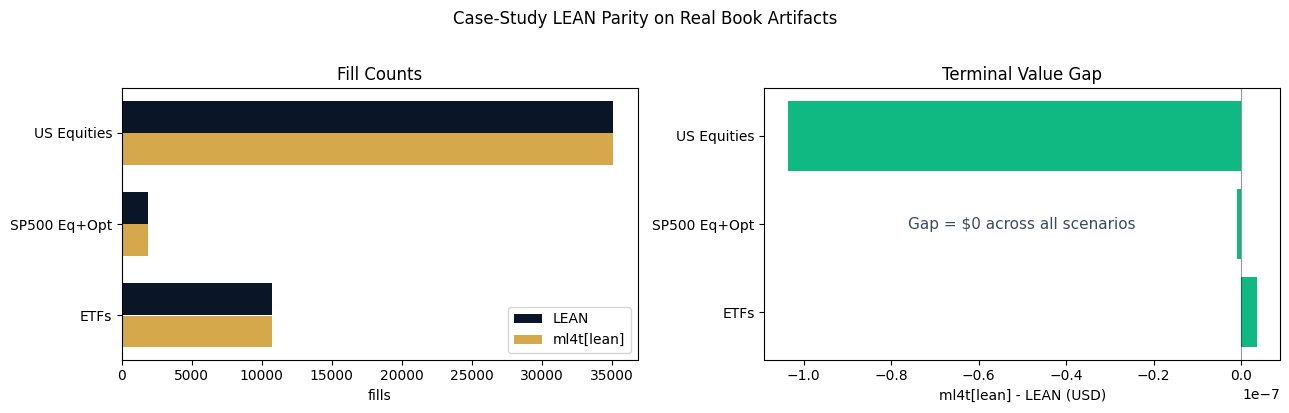

In [13]:
plot_df = results_df.sort("display")
labels = plot_df["display"].to_list()
y = range(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(
    [i + 0.18 for i in y],
    plot_df["lean_fills"].to_list(),
    height=0.35,
    color=COLORS["blue"],
    label="LEAN",
)
axes[0].barh(
    [i - 0.18 for i in y],
    plot_df["ml4t_fills"].to_list(),
    height=0.35,
    color=COLORS["amber"],
    label="ml4t[lean]",
)
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(labels)
axes[0].set_title("Fill Counts")
axes[0].set_xlabel("fills")
axes[0].legend()

_value_gaps = plot_df["final_value_gap_usd"].to_list()
axes[1].barh(labels, _value_gaps, color=COLORS["positive"])
axes[1].set_title("Terminal Value Gap")
axes[1].set_xlabel("ml4t[lean] - LEAN (USD)")
axes[1].axvline(0, color="black", linewidth=0.8, alpha=0.4)
if all(abs(v) < 1e-6 for v in _value_gaps):
    axes[1].text(
        0.5,
        0.5,
        "Gap = $0 across all scenarios",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=11,
        color=COLORS["slate"],
        alpha=0.85,
    )

fig.suptitle("Case-Study LEAN Parity on Real Book Artifacts", y=1.02)
fig.tight_layout()
fig.show()

## 6. Interpretation

This notebook is reader-facing evidence that the LEAN-matching profile is not
confined to one synthetic benchmark. It transfers to the same real case-study
data and target weights that drive the book's validation workflow.

In [14]:
matched = int(payload["summary"]["matched_case_studies"])
total = int(payload["summary"]["n_case_studies"])
max_gap = float(payload["summary"]["max_abs_final_value_gap_usd"])
raw_row_matches = int(results_df["raw_row_order_match"].sum())

print(f"Sorted fill multiset matches: {matched}/{total}")
print(f"Raw row-order matches:        {raw_row_matches}/{total}")
print(f"Max absolute value gap:       ${max_gap:.10f}")

Sorted fill multiset matches: 3/3
Raw row-order matches:        0/3
Max absolute value gap:       $0.0000001036


## Key Takeaways

1. **This is the reader-facing transfer proof.** The case-study parity path compares actual LEAN against `ml4t-backtest[lean]`, not one `ml4t` profile against another.

2. **The fill surface matches on all three daily case studies.** After normalizing to the daily fill identity key, the sorted fill multiset is exact for ETFs, S&P 500 equity-option analytics, and the US equities panel.

3. **Terminal portfolio values are equal to float noise.** The largest absolute gap in the cached artifact is about one ten-millionth of a dollar.

4. **Raw row order is a logging detail, not an economic gap.** Same-day fills can appear in a different asset iteration order while still representing the same executed daily fill set.

---
*Notebook: 16_case_study_lean_parity*
*ML4T 3rd Edition - Chapter 16: Strategy Simulation*